# Bat Weather Analysis
Fall 2024 data by night, which has a poor bat_pass distribution and only correlation found was wind speed is negatively correlated with number of bat passes

Author: K Rubio

Last Updated: May 2026


In [27]:
import pandas as pd
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr


In [20]:
!pip install jinja2


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
# have to modify where notebook looks for imports so it looks in the project root, not the notebook folder
os.getcwd()
sys.path.append(str(Path().resolve().parent.parent))
print(sys.path)

['/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python312.zip', '/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python3.12', '/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python3.12/lib-dynload', '', '/Users/dontfreakout/Documents/Education (reduced)/Computer_Science/Data_Science/Audio Signal Processing/Completed Projects/2026_Audio_Signal_Analysis/audio-signal-analysis/.venv/lib/python3.12/site-packages', '/Users/dontfreakout/Documents/Education (reduced)/Computer_Science/Data_Science/Audio Signal Processing/Completed Projects/2026_Audio_Signal_Analysis/audio-signal-analysis']


In [ ]:
filename = 'bat_weather_data_fall_2024.csv'
filepath = f'../data/datasets/{filename}'

In [ ]:
# import the data
df = pd.read_csv(filepath)
df.head()

,start_of_night,bat_passes,avg_wind_dir,avg_wind_speed,avg_gust_speed,avg_pressure,avg_temp,avg_dew_pt
0,9/16/24,317,190.153846,7.592308,8.084615,1024.215385,18.753846,12.792308
1,9/17/24,158,195.307692,5.184615,5.461538,1020.669231,19.523077,11.176923
2,9/18/24,40,147.230769,3.915385,4.284615,1016.776923,17.000000,17.000000
3,9/19/24,35,31.076923,6.076923,6.769231,1012.515385,17.330769,17.307692
4,9/20/24,1,39.461538,10.953846,12.600000,1015.876923,16.230769,13.230769


In [ ]:
predictors = ['avg_wind_dir', 'avg_wind_speed', 'avg_gust_speed', 'avg_pressure', 'avg_temp', 'avg_dew_pt']
outcome = ['bat_passes']

## Checking normality via histograms

In [11]:
def histogram(var):
    df[var].hist(bins=10, figsize=(6, 4))
    plt.title(var)
    plt.show()


count     29.000000
mean      24.517241
std       63.662963
min        0.000000
25%        1.000000
50%        4.000000
75%       20.000000
max      317.000000
Name: bat_passes, dtype: float64


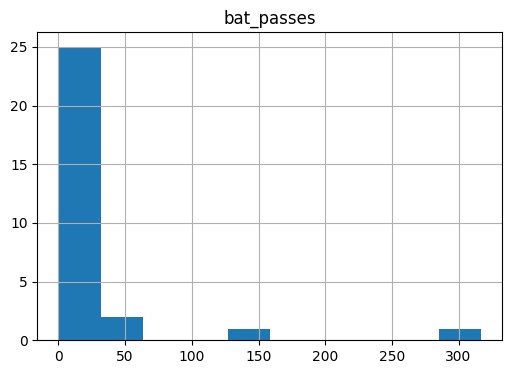

In [15]:
for col in outcomes:
    print(df[col].describe()) # check min, max, mean, quartiles, std
    histogram(col) # turning off to avoid uploading too many images to github
    print()

count     29.000000
mean     149.896110
std       89.786172
min       31.076923
25%       65.076923
50%      127.769231
75%      195.307692
max      301.461539
Name: avg_wind_dir, dtype: float64


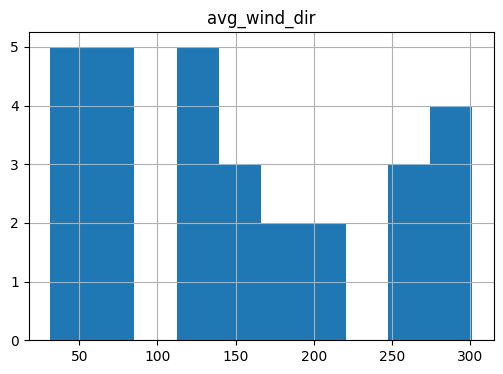


count    29.000000
mean      6.418081
std       2.144254
min       2.076923
25%       4.815385
50%       6.130769
75%       7.592308
max      10.953846
Name: avg_wind_speed, dtype: float64


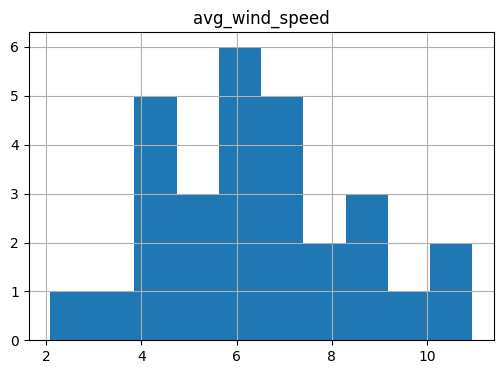


count    29.000000
mean      7.088506
std       2.430946
min       2.284615
25%       5.161538
50%       6.784615
75%       8.253846
max      12.600000
Name: avg_gust_speed, dtype: float64


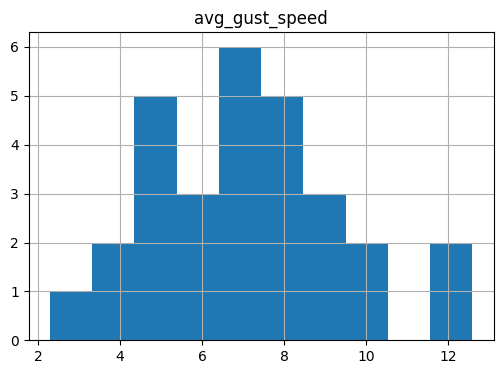


count      29.000000
mean     1015.793921
std         5.107261
min      1001.984615
25%      1012.515385
50%      1016.446154
75%      1019.600000
max      1024.215385
Name: avg_pressure, dtype: float64


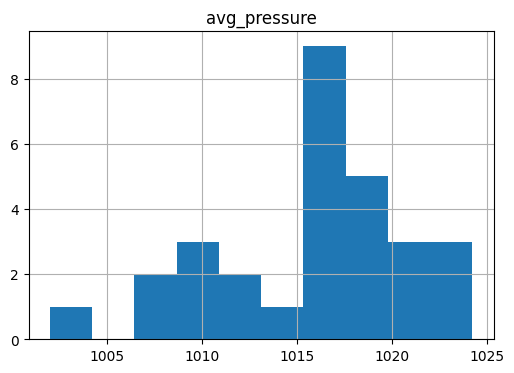


count    29.000000
mean     15.257206
std       2.383207
min       8.653846
25%      14.323077
50%      15.584615
75%      16.423077
max      19.523077
Name: avg_temp, dtype: float64


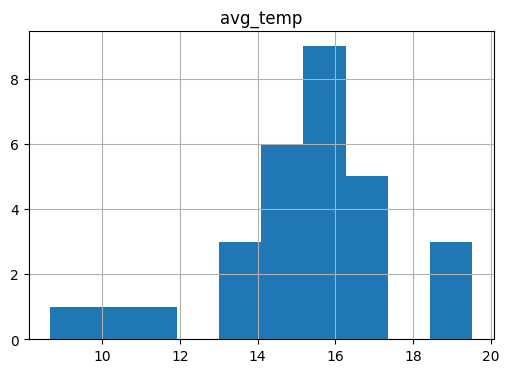


count    29.000000
mean      9.717153
std       5.496366
min      -5.230769
25%       8.569231
50%      11.353846
75%      13.230769
max      17.307692
Name: avg_dew_pt, dtype: float64


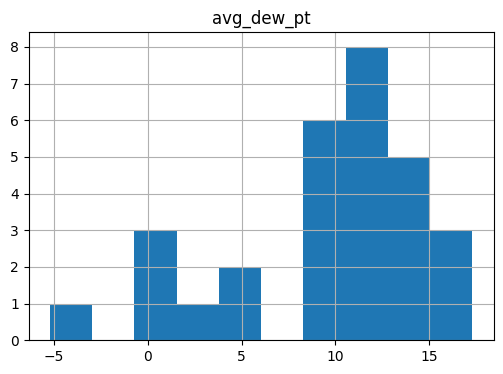

In [12]:
for col in predictors:
    print(df[col].describe()) # check min, max, mean, quartiles, std
    histogram(col) # turning off to avoid uploading too many images to github
    print()

## Check relationship between outcome and predictors, as well as multicollinearity
Hopefully each predictor is statistically different between the 2 groups, and also not too correlated with any other predictor

In [17]:
df2 = df.drop(['start_of_night'], axis=1)
df2.head()

,bat_passes,avg_wind_dir,avg_wind_speed,avg_gust_speed,avg_pressure,avg_temp,avg_dew_pt
0,317,190.153846,7.592308,8.084615,1024.215385,18.753846,12.792308
1,158,195.307692,5.184615,5.461538,1020.669231,19.523077,11.176923
2,40,147.230769,3.915385,4.284615,1016.776923,17.000000,17.000000
3,35,31.076923,6.076923,6.769231,1012.515385,17.330769,17.307692
4,1,39.461538,10.953846,12.600000,1015.876923,16.230769,13.230769


In [18]:
# Calculate the correlation matrix
correlation_matrix = df2.corr()


In [21]:
# Create a styled correlation table with color highlighting
styled_corr_table = correlation_matrix.style.background_gradient(cmap='coolwarm')


In [22]:
# Display the styled correlation table
styled_corr_table

,bat_passes,avg_wind_dir,avg_wind_speed,avg_gust_speed,avg_pressure,avg_temp,avg_dew_pt
bat_passes,1.000000,0.133319,-0.027389,-0.056807,0.327213,0.418514,0.143306
avg_wind_dir,0.133319,1.000000,0.109791,0.101316,-0.518321,-0.273014,-0.609418
avg_wind_speed,-0.027389,0.109791,1.000000,0.997483,-0.129449,-0.241313,-0.317431
avg_gust_speed,-0.056807,0.101316,0.997483,1.000000,-0.158660,-0.275975,-0.335106
avg_pressure,0.327213,-0.518321,-0.129449,-0.158660,1.000000,0.637464,0.504943
avg_temp,0.418514,-0.273014,-0.241313,-0.275975,0.637464,1.000000,0.504357
avg_dew_pt,0.143306,-0.609418,-0.317431,-0.335106,0.504943,0.504357,1.000000


bat_passes is negatively correlated to avg_wind_speed only
no other relationships with bat_passes and the predictors
no other multicollinearity among the predictors

In [28]:
# double-check with spearman's correlation since not normally distrivbuted
corr, p_value = spearmanr(df['bat_passes'], df['avg_wind_speed'])

print("Spearman correlation between bat_passes and avg_wind_speed:", corr)
print("P-value:", p_value)

Spearman correlation between bat_passes and avg_wind_speed: -0.30124849464204184
P-value: 0.11227331429127077


Per Spearman's correlation, there's no real relationship here

## Scatterplots

In [30]:
def make_scatterplot(var1, var2, x_label, y_label, title=''):
  # Create scatterplot
  plt.scatter(df[var1], df[var2])

  # Labels
  plt.title(title)
  plt.xlabel(x_label)
  plt.ylabel(y_label)

  # Show plot
  plt.show()

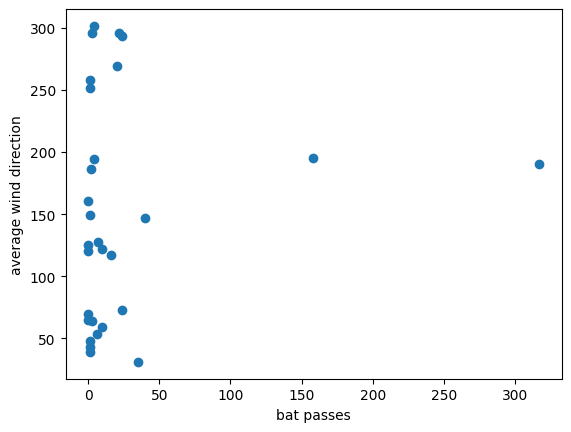

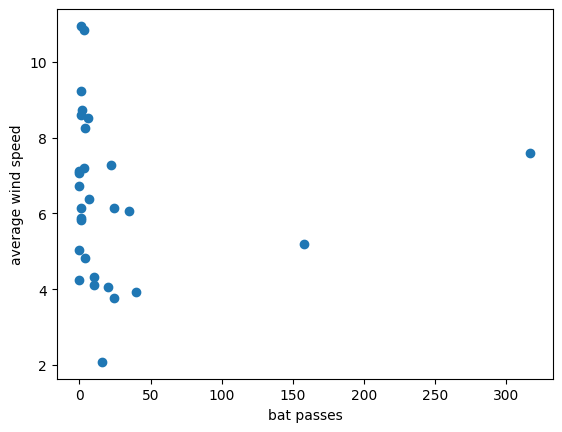

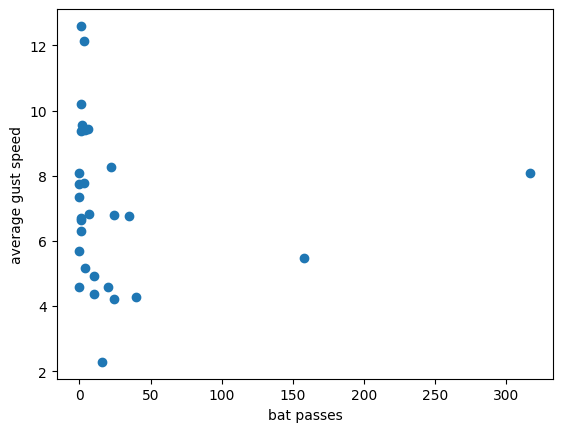

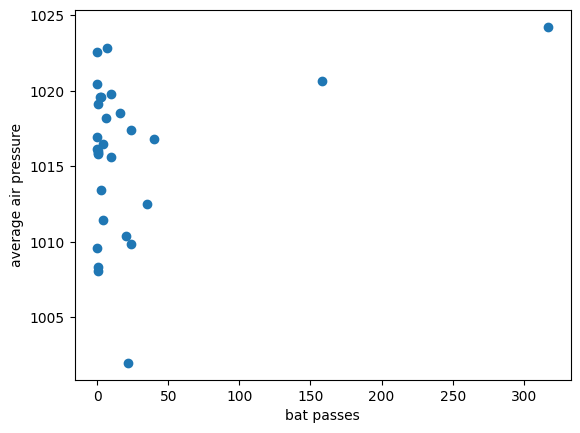

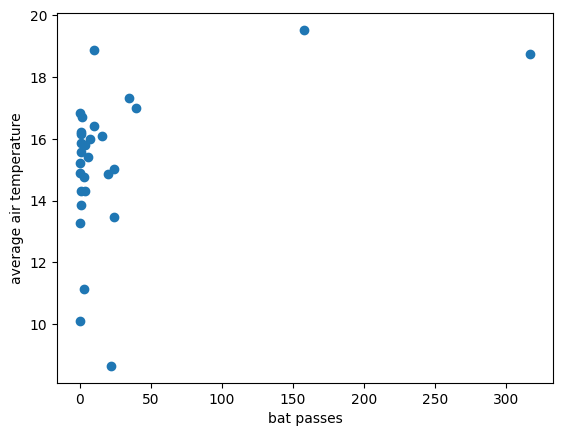

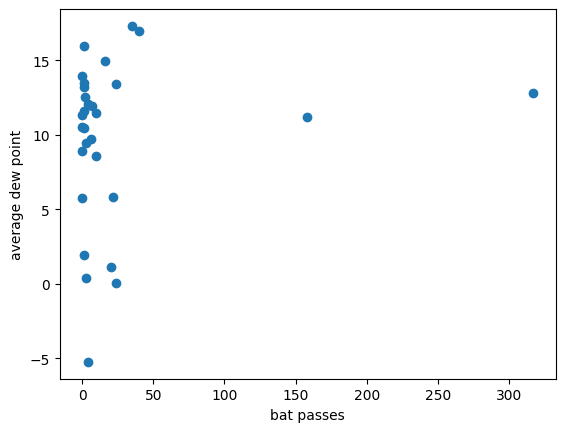

In [32]:

#predictors = ['avg_wind_dir', 'avg_wind_speed', 'avg_gust_speed', 'avg_pressure', 'avg_temp', 'avg_dew_pt']
make_scatterplot('bat_passes', 'avg_wind_dir', 'bat passes', 'average wind direction')
make_scatterplot('bat_passes', 'avg_wind_speed', 'bat passes', 'average wind speed')
make_scatterplot('bat_passes', 'avg_gust_speed', 'bat passes', 'average gust speed')
make_scatterplot('bat_passes', 'avg_pressure', 'bat passes', 'average air pressure')
make_scatterplot('bat_passes', 'avg_temp', 'bat passes', 'average air temperature')
make_scatterplot('bat_passes', 'avg_dew_pt', 'bat passes', 'average dew point')
